# Dataset tests

Run one 32-token prompt from a text dataset through a single model using the analyzer pipeline. If needed, swap `DatasetPromptSource` for `RandomTokenPromptSource` without changing the rest of the code.

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM


def compute_cosine_sim_distribution(
    model_name: str = "Qwen/Qwen2.5-0.5B-Instruct",
    chunk_size: int = 512,
    n_bins: int = 200,
):
    """
    Computes the full pairwise cosine similarity distribution over all tokens
    without materializing the V×V matrix.

    Strategy: stream rows in chunks of `chunk_size`, accumulate a histogram
    bin-by-bin instead of storing individual values.

    Memory peak: chunk_size × V × 4 bytes
      e.g. chunk=512, V=151k → ~310 MB peak, regardless of V.
    """
    print(f"[Info] Loading model: {model_name}")
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        device_map="cpu",
        trust_remote_code=True,
        torch_dtype=torch.float32,
    )

    if hasattr(model, "model") and hasattr(model.model, "embed_tokens"):
        E = model.model.embed_tokens.weight.detach()
    else:
        E = model.get_input_embeddings().weight.detach()

    V, d = E.shape
    print(f"[Info] Embedding matrix: {V} tokens × {d} dimensions")

    # -----------------------------------------------------------------------
    # Step 1: Normalize all embeddings to unit length — O(V × d), fine.
    # -----------------------------------------------------------------------
    norms = torch.norm(E, dim=1, keepdim=True).clamp(min=1e-8)
    E_hat = E / norms  # (V, d)

    # -----------------------------------------------------------------------
    # Step 2: Exact mean via the algebraic identity — O(d), negligible.
    # -----------------------------------------------------------------------
    mean_vec = E_hat.sum(dim=0)               # (d,)
    sum_of_sq = mean_vec.dot(mean_vec).item() # ||Σ ê_i||²
    exact_mean = (sum_of_sq - V) / (V * (V - 1))
    print(f"[Info] Exact mean cosine similarity (all pairs): {exact_mean:.6f}")

    # -----------------------------------------------------------------------
    # Step 3: Histogram via row-chunk streaming.
    # For chunk rows i, compute sim(i, j) for all j > i (upper triangle only).
    # Accumulate into a fixed-size histogram to avoid storing V² values.
    # -----------------------------------------------------------------------
    bin_edges = np.linspace(-1.0, 1.0, n_bins + 1)
    histogram  = np.zeros(n_bins, dtype=np.float64)

    n_chunks = (V + chunk_size - 1) // chunk_size
    total_pairs = V * (V - 1) // 2
    processed_pairs = 0

    print(f"[Info] Streaming {n_chunks} chunks of {chunk_size} rows...")
    for chunk_start in range(0, V, chunk_size):
        chunk_end = min(chunk_start + chunk_size, V)
        chunk = E_hat[chunk_start:chunk_end]  # (chunk, d)

        # Similarity of this chunk against all tokens with index > chunk
        # We only compute upper-triangle to avoid double counting.
        # sim_block[i, j] = cos(chunk_start+i, j) for j > chunk_start+i
        sim_block = chunk @ E_hat.T            # (chunk, V)

        for local_i, global_i in enumerate(range(chunk_start, chunk_end)):
            # Upper-triangle: only j > global_i
            row = sim_block[local_i, global_i + 1:]   # (V - global_i - 1,)
            if row.numel() == 0:
                continue
            counts, _ = np.histogram(row.numpy(), bins=bin_edges)
            histogram += counts
            processed_pairs += row.numel()

        pct = 100 * processed_pairs / total_pairs
        print(f"\r  Progress: {pct:.1f}%  ({processed_pairs:,} / {total_pairs:,} pairs)", end="")

    print(f"\n[Info] Total pairs processed: {processed_pairs:,}")

    # -----------------------------------------------------------------------
    # Step 4: Plot — log-scale y axis
    # -----------------------------------------------------------------------
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    density = histogram / (histogram.sum() * (bin_edges[1] - bin_edges[0]))

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(bin_centers, density, width=bin_edges[1] - bin_edges[0],
           color="teal", alpha=0.75, label="Empirical density")
    ax.axvline(exact_mean, color="crimson", linestyle="--", linewidth=1.8,
               label=f"Mean = {exact_mean:.4f}")
    ax.set_yscale("log")
    ax.set_xlabel("Pairwise Cosine Similarity", fontsize=12)
    ax.set_ylabel("Density (log scale)", fontsize=12)
    ax.set_title(
        f"Token Embedding Cosine Similarity — {model_name}\n"
        f"V = {V}, d = {d}, pairs = {total_pairs:,}",
        fontsize=11,
    )
    ax.legend()
    plt.tight_layout()
    plt.savefig("cosine_sim_distribution.png", dpi=300)
    print("[Info] Saved → cosine_sim_distribution.png")

    return {
        "exact_mean_cosine_sim": exact_mean,
        "total_pairs": total_pairs,
        "histogram": histogram,
        "bin_edges": bin_edges,
    }

compute_cosine_sim_distribution("Qwen/Qwen3-4B", chunk_size=512)

In [ ]:
import pandas as pd


df = pd.read_parquet('Qwen3_4B_512tok.parquet')

In [ ]:
# Focused EDA: correlations + WqRWk alignment heatmaps (from FEATURE_REGISTRY)
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
from core.features_library import FEATURE_REGISTRY
pio.renderers.default = "vscode"

sources = sorted(df["prompt_source"].dropna().astype(str).unique().tolist())
print("Prompt sources:", sources)

META_COLS = {"model_name", "prompt_id", "prompt_source", "layer_idx", "head_idx", "run_idx"}

# All numeric features in the dataset (not only registry columns).
all_numeric_features = [
    c for c in df.columns
    if pd.api.types.is_numeric_dtype(df[c]) and c not in META_COLS
]

registry_features = list(FEATURE_REGISTRY.keys())
available_registry_features = [f for f in registry_features if f in df.columns]
print(f"Registry features found in df: {len(available_registry_features)}/{len(registry_features)}")
print(f"Total numeric features used for correlation: {len(all_numeric_features)}")

# Canonical feature groups from features_library naming.
model_dependent_features = [
    "effective_rank_Wq", "r95_Wq",
    "effective_rank_Wk", "r95_Wk",
    "effective_rank_Wv", "r95_Wv",
    "rmsnorm_gamma_norm",
    "rope_pair_var_Wq", "rope_pair_var_Wk",
    "rope_pair_max_norm_Wq", "rope_pair_max_norm_Wk",
    "rope_pair_max_ratio_Wq", "rope_pair_max_ratio_Wk",
    "rope_freq_com_Wq", "rope_freq_com_Wk",
    "compute_WqRWk_alignment_delta_0",
    "compute_WqRWk_alignment_delta_1",
    "compute_WqRWk_alignment_delta_2",
    "compute_WqRWk_alignment_delta_3",
    "compute_WqRWk_alignment_delta_4",
]

input_dependent_features = [
    "effective_rank_H", "r95_H",
    "effective_rank_Q", "r95_Q",
    "effective_rank_K", "r95_K",
    "q_sim_consecutive", "k_sim_consecutive",
    "svd_alignment_H_Wq", "svd_alignment_H_Wk",
]

target_features = [
    "attention_entropy", "attention_gini", "attention_row_var_weighted",
    "diagonal_mass_1", "diagonal_mass_5",
    "diagonal_mass_1_shifted_1", "diagonal_mass_1_shifted_2",
    "diagonal_mass_1_shifted_3", "diagonal_mass_1_shifted_4",
    "sink_mass_token_0", "sink_mass_token_1", "sink_mass_token_2",
    "sink_mass_token_3", "sink_mass_token_4", "sink_mass_max",
    "look_back",
    "effective_rank_A", "r95_A",
]

model_set = set(model_dependent_features)
input_set = set(input_dependent_features)
target_set = set(target_features)

def classify_feature(name):
    if name in model_set:
        return "model"
    if name in input_set:
        return "input"
    if name in target_set:
        return "target"

    n = name.lower()
    if any(k in n for k in ["wq", "wk", "wv", "weight", "rope", "rmsnorm", "gamma"]):
        return "model"
    if any(k in n for k in ["_h", "_q", "_k", "q_sim", "k_sim", "svd_alignment_h"]):
        return "input"
    return "target"

def ordered_group(features, canonical_order):
    present = [f for f in canonical_order if f in features]
    rest = sorted([f for f in features if f not in set(canonical_order)], key=str.lower)
    return present + rest

model_group = [f for f in all_numeric_features if classify_feature(f) == "model"]
input_group = [f for f in all_numeric_features if classify_feature(f) == "input"]
target_group = [f for f in all_numeric_features if classify_feature(f) == "target"]

model_group = ordered_group(model_group, model_dependent_features)
input_group = ordered_group(input_group, input_dependent_features)
target_group = ordered_group(target_group, target_features)

sorted_features = model_group + input_group + target_group

print("Feature ordering for correlation:")
print("  model-dependent:", len(model_group))
print("  input-dependent:", len(input_group))
print("  target:", len(target_group))

# Boundaries used to draw dividers between the three blocks.
b1 = len(model_group)
b2 = len(model_group) + len(input_group)
boundaries = [b for b in [b1, b2] if 0 < b < len(sorted_features)]

def add_group_dividers(fig, n_features, boundaries):
    for b in boundaries:
        pos = b - 0.5
        fig.add_shape(
            type="line",
            x0=pos, x1=pos, y0=-0.5, y1=n_features - 0.5,
            line=dict(color="black", width=2),
        )
        fig.add_shape(
            type="line",
            x0=-0.5, x1=n_features - 0.5, y0=pos, y1=pos,
            line=dict(color="black", width=2),
        )

def find_source(keyword, fallback_index=None):
    matches = [s for s in sources if keyword in s.lower()]
    if matches:
        return matches[0]
    if fallback_index is not None and fallback_index < len(sources):
        return sources[fallback_index]
    return None

random_source = find_source("random", fallback_index=0)
wikitext_source = find_source("wiki", fallback_index=1 if len(sources) > 1 else 0)

for label, src in [("Random dataset", random_source), ("WikiText dataset", wikitext_source)]:
    if src is None:
        print(f"[Skip] {label}: source not found in prompt_source column.")
        continue

    sub = df[df["prompt_source"] == src]
    if sub.empty:
        print(f"[Skip] {label}: no rows for source={src}.")
        continue

    corr = sub[sorted_features].corr()
    fig = px.imshow(
        corr,
        color_continuous_scale="RdBu_r",
        zmin=-1,
        zmax=1,
        title=f"<b>Correlation Matrix</b> — {label} ({src})",
        labels={"x": "Feature", "y": "Feature", "color": "Correlation"},
    )
    fig.update_xaxes(tickangle=-45)
    add_group_dividers(fig, n_features=len(sorted_features), boundaries=boundaries)
    fig.update_layout(width=1000, height=900)
    fig.show()

# Exact WqRWk alignment feature names from FEATURE_REGISTRY.
wqrwk_alignment_feats = [
    f for f in available_registry_features if f.startswith("compute_WqRWk_alignment_delta_")
]

# Enforce delta order 0..4.
wqrwk_alignment_feats = sorted(wqrwk_alignment_feats, key=lambda s: int(s.rsplit("_", 1)[-1]))

if not wqrwk_alignment_feats:
    print("[Skip] No compute_WqRWk_alignment_delta_* columns found.")
else:
    print("WqRWk alignment features:", wqrwk_alignment_feats)

for feat in wqrwk_alignment_feats:
    fig = make_subplots(
        rows=1,
        cols=max(1, len(sources)),
        subplot_titles=[f"{s} (n={int((df['prompt_source'] == s).sum())})" for s in sources],
        shared_yaxes=True,
    )

    global_vals = df[feat].dropna()
    zmin = float(global_vals.min()) if not global_vals.empty else None
    zmax = float(global_vals.max()) if not global_vals.empty else None

    for col_idx, src in enumerate(sources, start=1):
        sub = df[df["prompt_source"] == src]
        agg = (
            sub.groupby(["head_idx", "layer_idx"], as_index=False)[feat]
            .mean()
            .sort_values(["head_idx", "layer_idx"])
)

        pivot = agg.pivot(index="head_idx", columns="layer_idx", values=feat)
        pivot = pivot.sort_index().sort_index(axis=1)

        fig.add_trace(
            go.Heatmap(
                z=pivot.values,
                x=pivot.columns,
                y=pivot.index,
                coloraxis="coloraxis",
                hovertemplate="Layer=%{x}<br>Head=%{y}<br>value=%{z:.4f}<extra></extra>",
            ),
            row=1,
            col=col_idx,
        )

        fig.update_xaxes(title_text="Layer", row=1, col=col_idx)
        fig.update_yaxes(title_text="Head", row=1, col=col_idx)

    fig.update_layout(
        title=f"<b>{feat}</b> — layer x head heatmap by prompt type (mean over prompts)",
        coloraxis=dict(colorscale="Viridis", cmin=zmin, cmax=zmax, colorbar_title=feat),
        width=max(520 * max(1, len(sources)), 950),
        height=500,
)
    fig.show()

# test

In [13]:
# ============================================================
#  rho_slash_experiment.py
#  Verifica empirica: ρ(Δ=1) >> ρ(Δ=0)  per slash heads?
#  Modello: Qwen3-4B  |  Layer: 0
# ============================================================

# ── CELL 1: Imports ─────────────────────────────────────────
import torch
import numpy as np
import math
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset

warnings.filterwarnings("ignore")
torch.set_grad_enabled(False)


# ── CELL 2: Config ──────────────────────────────────────────
MODEL_NAME  = "Qwen/Qwen3-4B"
LAYER_IDX   = 0
DELTAS      = [0, 1, 2, 3, 4, 5, 10, 20]
SEQ_LEN     = 64      # token per prompt
N_RANDOM    = 1      # prompt random vocab
N_WIKI      = 1      # prompt da wikitext
SEED        = 42


In [2]:

# ── CELL 3: Carica il modello ────────────────────────────────
print(f"[1/5] Caricamento {MODEL_NAME} …")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype="auto",
    trust_remote_code=True,
)
model.eval()
device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

cfg        = model.config
d_model    = cfg.hidden_size
num_heads  = cfg.num_attention_heads
num_kv     = cfg.num_key_value_heads
d_head     = getattr(cfg, "head_dim", d_model // num_heads)
theta_base = float(getattr(cfg, "rope_theta", 1000000.0))
group_size = num_heads // num_kv   # numero di Q-heads per KV-head

print(f"    d_model={d_model}  num_heads={num_heads}  num_kv={num_kv}"
      f"  d_head={d_head}  θ_base={theta_base}  device={device}")

# ── CELL 4: Estrai W_q, W_k del layer scelto ────────────────
attn_mod = model.model.layers[LAYER_IDX].self_attn
W_q = attn_mod.q_proj.weight.data   # [num_heads*d_head, d_model]
W_k = attn_mod.k_proj.weight.data   # [num_kv*d_head,    d_model]
print(f"    W_q: {tuple(W_q.shape)}, W_k: {tuple(W_k.shape)}")


[1/5] Caricamento Qwen/Qwen3-4B …


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 1396.05it/s, Materializing param=model.norm.weight]                              


    d_model=2560  num_heads=32  num_kv=8  d_head=128  θ_base=1000000.0  device=mps
    W_q: (4096, 2560), W_k: (1024, 2560)


In [3]:
print(theta_base)


1000000.0


In [10]:

# ── CELL 5: Funzioni per ρ(Δ) ───────────────────────────────
def build_R(delta: int, d_head: int, theta_base: float,
            device, dtype) -> torch.Tensor:
    """
    Matrice di rotazione RoPE R_Δ ∈ R^{d_head × d_head}.
    Block-diagonale: ogni blocco 2×2 ruota di θ_k·Δ.
    """
    R = torch.eye(d_head, device=device, dtype=torch.float32)
    for k in range(d_head // 2):
        th  = theta_base ** (-2.0 * k / d_head)
        a   = th * delta
        c, s = math.cos(a), math.sin(a)
        R[2*k,   2*k  ] =  c;  R[2*k,   2*k+1] = -s
        R[2*k+1, 2*k  ] =  s;  R[2*k+1, 2*k+1] =  c
    return R

def compute_rho_from_M0(M0: torch.Tensor, delta: int, theta_base: float,
                         top_k: int = 2) -> float:
    """
    ρ(Δ) = Σ_{n=1}^{K} (σ_n / Σσ_topK) · <u_n, v_n>

    top_k=None  → spettro completo (comportamento precedente)
    top_k=2     → solo i 2 vettori singolari dominanti
    """
    d_head = M0.shape[0]
    R  = build_R(delta, d_head, theta_base, M0.device, M0.dtype)
    M  = (M0 @ R.T).float()
    U, S, Vh = torch.linalg.svd(M, full_matrices=False)  # U,Vh: [d,d], S: [d]

    if top_k is not None:
        U  = U[:, :top_k]   # [d_head, top_k]
        S  = S[:top_k]      # [top_k]
        Vh = Vh[:top_k, :]  # [top_k, d_head]

    V       = Vh.T                          # [d_head, top_k]
    cos_sim = (U * V).sum(dim=0)            # <u_n, v_n> per n=1..K
    weights = S / (S.sum() + 1e-12)        # normalizzato sui soli top_k
    return float((weights * cos_sim).sum())


In [14]:

# ── CELL 6: Calcola ρ(Δ) per ogni head ──────────────────────
print(f"\n[2/5] Calcolo ρ(Δ) per {num_heads} heads (layer {LAYER_IDX}) …")
rho_matrix = np.zeros((num_heads, len(DELTAS)))   # [H, |DELTAS|]


# Loop corretto:
with torch.no_grad():
    for h in range(num_heads):
        kv   = h // group_size
        Wq_h = W_q[h  * d_head : (h+1)  * d_head, :]   # [d_head, d_model]
        Wk_h = W_k[kv * d_head : (kv+1) * d_head, :]   # [d_head, d_model]
        M0   = Wq_h @ Wk_h.T                            # [d_head, d_head] — una volta sola
        for j, delta in enumerate(DELTAS):
            rho_matrix[h, j] = compute_rho_from_M0(M0, delta, theta_base)

# Stampa tabella
header = "Head | " + " | ".join([f"ρ(Δ={d})" for d in DELTAS])
print("\n" + header)
print("-" * len(header))
for h in range(num_heads):
    row = " | ".join([f"{rho_matrix[h,j]:+.4f}" for j in range(len(DELTAS))])
    print(f"{h:>4} | {row}")



[2/5] Calcolo ρ(Δ) per 32 heads (layer 0) …

Head | ρ(Δ=0) | ρ(Δ=1) | ρ(Δ=2) | ρ(Δ=3) | ρ(Δ=4) | ρ(Δ=5) | ρ(Δ=10) | ρ(Δ=20)
------------------------------------------------------------------------------
   0 | +0.3578 | +0.3590 | +0.3591 | +0.3559 | +0.3488 | +0.3399 | +0.3151 | +0.2586
   1 | +0.3836 | +0.4073 | +0.3868 | +0.3153 | +0.2310 | +0.1923 | +0.2739 | +0.1937
   2 | +0.6300 | +0.5896 | +0.4754 | +0.3520 | +0.2854 | +0.3004 | +0.4202 | +0.3291
   3 | +0.4496 | +0.4391 | +0.4299 | +0.4269 | +0.4302 | +0.4362 | +0.4125 | +0.3869
   4 | -0.0530 | -0.0511 | -0.0486 | -0.0496 | -0.0561 | -0.0655 | -0.0749 | -0.1295
   5 | +0.3644 | +0.3555 | +0.3383 | +0.3195 | +0.3040 | +0.2933 | +0.2609 | +0.2187
   6 | +0.1660 | +0.1670 | +0.1689 | +0.1685 | +0.1646 | +0.1588 | +0.1426 | +0.0667
   7 | -0.1002 | -0.1013 | -0.1028 | -0.1049 | -0.1076 | -0.1106 | -0.1114 | -0.1639
   8 | +0.1631 | +0.1674 | +0.1624 | +0.1489 | +0.1283 | +0.1040 | +0.0580 | -0.0357
   9 | +0.6026 | +0.5709 | +0.4

In [6]:

# ── CELL 7: Costruisci i prompt ──────────────────────────────
print(f"\n[3/5] Costruzione prompt …")
rng = np.random.default_rng(SEED)

# 10 prompt random: token campionati uniformemente nel vocabolario
# (escludiamo i token speciali, tipicamente i primi 4)
vocab_ids  = list(range(5, tokenizer.vocab_size))
rand_texts = []
for _ in range(N_RANDOM):
    ids = rng.choice(vocab_ids, size=SEQ_LEN, replace=True).tolist()
    rand_texts.append(tokenizer.decode(ids, skip_special_tokens=True))

# 10 prompt wikitext-103
ds = load_dataset("wikitext", "wikitext-103-raw-v1",
                  split="train", streaming=True, trust_remote_code=True)
wiki_texts = []
for ex in ds:
    t = ex["text"].strip()
    if len(t) > 200:
        wiki_texts.append(t[:600])
    if len(wiki_texts) == N_WIKI:
        break

all_texts  = rand_texts  + wiki_texts
all_labels = ["random"] * N_RANDOM + ["wikitext"] * N_WIKI
print(f"    Prompt pronti: {len(rand_texts)} random + {len(wiki_texts)} wikitext")



[3/5] Costruzione prompt …


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'wikitext' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
python(9575) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


    Prompt pronti: 1 random + 1 wikitext


In [7]:
# ── CELL 8 (riscritta) ──────────────────────────────────────
# Strategia: SDPA per tutto il modello (veloce),
# hook leggero sull'input di layer 0,
# attenzione di layer 0 ricalcolata a mano.

import math, torch
print(f"\n[4/5] Forward pass e calcolo slash mass …")

# Rimuovi TUTTI gli hook da TUTTI i moduli del modello
removed = 0
for name, mod in model.named_modules():
    n_pre  = len(mod._forward_pre_hooks)
    n_post = len(mod._forward_hooks)
    mod._forward_pre_hooks.clear()
    mod._forward_hooks.clear()
    removed += n_pre + n_post

print(f"Hook rimossi: {removed}")
# ── RoPE (variant half-rotate, uguale a Qwen3) ──────────────
def rotate_half(x: torch.Tensor) -> torch.Tensor:
    x1, x2 = x[..., : x.shape[-1] // 2], x[..., x.shape[-1] // 2 :]
    return torch.cat([-x2, x1], dim=-1)

def apply_rope(x: torch.Tensor, theta_base: float) -> torch.Tensor:
    """x : [B, H, T, d_head]"""
    B, H, T, d = x.shape
    pos   = torch.arange(T, dtype=torch.float32, device=x.device)
    freqs = theta_base ** (
        -torch.arange(0, d, 2, dtype=torch.float32, device=x.device) / d
    )
    angles = torch.outer(pos, freqs)            # [T, d//2]
    emb    = torch.cat([angles, angles], dim=-1)[None, None]  # [1,1,T,d]
    cos    = emb.cos().to(x.dtype)
    sin    = emb.sin().to(x.dtype)
    return x * cos + rotate_half(x) * sin

# ── Diagonal mass ────────────────────────────────────────────
def diagonal_mass_fn(A: torch.Tensor, shift: int = 0, band_width: int = 1) -> float:
    T    = A.shape[0]
    row  = torch.arange(T, dtype=torch.float32).unsqueeze(1)
    col  = torch.arange(T, dtype=torch.float32).unsqueeze(0)
    mask = (torch.abs((row - col) - shift) <= band_width // 2).float()
    tot  = A.sum()
    return float("nan") if tot < 1e-12 else float((A * mask).sum() / tot)

# ── Pesi su CPU float32 ──────────────────────────────────────
Wq_cpu = W_q.float().cpu()   # [num_heads*d_head, d_model]
Wk_cpu = W_k.float().cpu()   # [num_kv*d_head,    d_model]

# ── Hook: cattura hidden states dopo layernorm, prima dell'attenzione ──
h_cache = {}

# Hook su input_layernorm: il suo output = hidden states normalizzati
# che vengono passati a self_attn per proiettare Q, K, V
hook = model.model.layers[LAYER_IDX].input_layernorm.register_forward_hook(
    lambda m, inp, out: h_cache.update({'h': out.detach().cpu().float()})
)
# ── Loop sui prompt ──────────────────────────────────────────
records = []

with torch.no_grad():
    for idx, (text, label) in enumerate(zip(all_texts, all_labels)):
        enc = tokenizer(text, return_tensors="pt",
                        truncation=True, max_length=SEQ_LEN)
        inp = enc["input_ids"].to(device)
        T   = inp.shape[1]
        if T < 10:
            continue

        h_cache.clear()
        _ = model(inp)           # forward SDPA, nessun output_attentions

        if 'h' not in h_cache:
            continue

        h = h_cache['h']         # [1, T, d_model]
        B = h.shape[0]

        # Proiezioni Q, K
        Q = (h @ Wq_cpu.T).view(B, T, num_heads, d_head).permute(0, 2, 1, 3)
        K = (h @ Wk_cpu.T).view(B, T, num_kv,   d_head).permute(0, 2, 1, 3)

        # RoPE
        Q = apply_rope(Q, theta_base)
        K = apply_rope(K, theta_base)

        # Espandi K per GQA: num_kv → num_heads
        K = K.repeat_interleave(group_size, dim=1)   # [B, H, T, d_head]

        # Scores + causal mask + softmax
        scale  = math.sqrt(d_head)
        S      = torch.matmul(Q, K.transpose(-2, -1)) / scale  # [B, H, T, T]
        causal = torch.triu(torch.full((T, T), float('-inf')), diagonal=1)
        S     += causal[None, None]
        A_all  = torch.softmax(S.float(), dim=-1)    # [B, H, T, T]

        for h_idx in range(num_heads):
            A_h = A_all[0, h_idx]
            records.append({
                "prompt_idx"         : idx,
                "label"              : label,
                "head"               : h_idx,
                "seq_len"            : T,
                "diag_mass_0"        : diagonal_mass_fn(A_h, shift=0),
                "diag_mass_shifted_1": diagonal_mass_fn(A_h, shift=1),
                **{f"rho_{d}": rho_matrix[h_idx, j] for j, d in enumerate(DELTAS)},
            })
        del Q, K, S, A_all

hook.remove()
df = pd.DataFrame(records)
print(f"    Raccolti {len(df)} osservazioni  ({len(all_texts)} prompt × {num_heads} heads)")


[4/5] Forward pass e calcolo slash mass …
Hook rimossi: 0
    Raccolti 64 osservazioni  (2 prompt × 32 heads)


In [18]:
# ── CELL 9: Analisi statistica ───────────────────────────────
print(f"\n[5/5] Verifica empirica ρ(Δ) vs slash mass …\n")

rho_cols = sorted(
    [col for col in df.columns if col.startswith("rho_")],
    key=lambda col: int(col.split("_")[1])
)
available_deltas = [int(col.split("_")[1]) for col in rho_cols]

# ─ (a) Correlazioni globali (tutte le osservazioni) ─
for target_Δ in available_deltas:
    rho_col = f"rho_{target_Δ}"
    r_self, p_self = spearmanr(df[rho_col], df["diag_mass_0"])
    r_slash, p_slash = spearmanr(df[rho_col], df["diag_mass_shifted_1"])

    print(f"  ρ(Δ={target_Δ})  vs  diag_mass_0          : r={r_self:+.4f}  p={p_self:.2e}")
    print(f"  ρ(Δ={target_Δ})  vs  diag_mass_shifted_1  : r={r_slash:+.4f}  p={p_slash:.2e}")
    print()

# ─ (b) Per-head: aggregazione media delle slash mass ─
agg_spec = {col: (col, "first") for col in rho_cols}
agg_spec.update(
    dm_self=("diag_mass_0", "mean"),
    dm_slash_1=("diag_mass_shifted_1", "mean"),
)
head_df = df.groupby("head").agg(**agg_spec).reset_index()

if "rho_1" in head_df.columns and "rho_0" in head_df.columns:
    head_df["rho_diff_10"] = head_df["rho_1"] - head_df["rho_0"]  # ρ(1) - ρ(0)
else:
    head_df["rho_diff_10"] = np.nan

print("─ Per-head (aggregato sui prompt) ─")
print(f"{'H':>3} | {'ρ(0)':>7} | {'ρ(1)':>7} | {'Δρ=ρ(1)-ρ(0)':>13} | {'dm_self':>8} | {'dm_slash1':>10}")
print("-" * 60)
for _, row in head_df.iterrows():
    rho0 = row["rho_0"] if "rho_0" in row.index else float("nan")
    rho1 = row["rho_1"] if "rho_1" in row.index else float("nan")
    print(f"{int(row['head']):>3} | {rho0:>+7.4f} | {rho1:>+7.4f} | "
          f"{row.rho_diff_10:>+13.4f} | {row.dm_self:>8.4f} | {row.dm_slash_1:>10.4f}")

# ─ (c) Correlazione chiave ─
valid = head_df[["rho_diff_10", "dm_slash_1"]].dropna()
if len(valid) >= 2:
    r_key, p_key = spearmanr(valid["rho_diff_10"], valid["dm_slash_1"])
    print(f"\n★  Spearman( ρ(1)−ρ(0)  ,  mean(diag_mass_shifted_1) ) = {r_key:+.4f}  p={p_key:.3e}")
    if r_key > 0.3 and p_key < 0.05:
        print("    → CONFERMATO: le slash heads hanno tendenzialmente ρ(1) > ρ(0)")
    elif r_key > 0.0:
        print("    → Tendenza positiva ma debole: corrispondenza parziale")
    else:
        print("    → NON confermato: il picco di ρ non predice le slash heads")
        print("    → Probabile motivo: frequenze RoPE dominanti nelle KV-heads troppo basse,")
        print("      la funzione ρ è quasi piatta per Δ ∈ {0..4}.")
else:
    print("\n★  Correlazione chiave non calcolabile: servono sia ρ(0) sia ρ(1).")


[5/5] Verifica empirica ρ(Δ) vs slash mass …

  ρ(Δ=0)  vs  diag_mass_0          : r=+0.6843  p=4.54e-10
  ρ(Δ=0)  vs  diag_mass_shifted_1  : r=-0.1231  p=3.32e-01

  ρ(Δ=1)  vs  diag_mass_0          : r=+0.6843  p=4.54e-10
  ρ(Δ=1)  vs  diag_mass_shifted_1  : r=-0.1231  p=3.32e-01

  ρ(Δ=2)  vs  diag_mass_0          : r=+0.6813  p=5.80e-10
  ρ(Δ=2)  vs  diag_mass_shifted_1  : r=-0.1255  p=3.23e-01

  ρ(Δ=3)  vs  diag_mass_0          : r=+0.6756  p=9.10e-10
  ρ(Δ=3)  vs  diag_mass_shifted_1  : r=-0.1344  p=2.90e-01

  ρ(Δ=4)  vs  diag_mass_0          : r=+0.6742  p=1.01e-09
  ρ(Δ=4)  vs  diag_mass_shifted_1  : r=-0.1338  p=2.92e-01

─ Per-head (aggregato sui prompt) ─
  H |    ρ(0) |    ρ(1) |  Δρ=ρ(1)-ρ(0) |  dm_self |  dm_slash1
------------------------------------------------------------
  0 | -0.2053 | -0.2012 |       +0.0042 |   0.0742 |     0.0585
  1 | -0.1267 | -0.1138 |       +0.0129 |   0.0745 |     0.0594
  2 | +0.7358 | +0.7211 |       -0.0147 |   0.0747 |     0.0588
  3 |

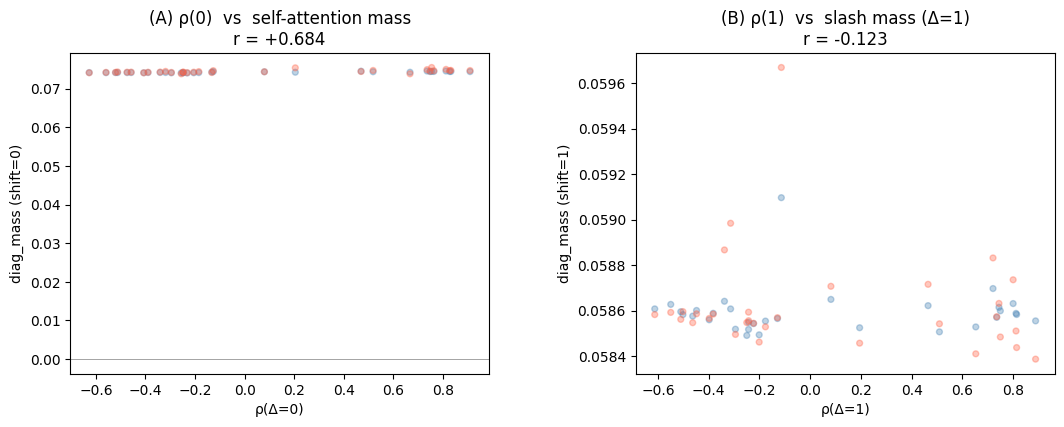

In [12]:

# ── CELL 10: Visualizzazione ─────────────────────────────────
fig = plt.figure(figsize=(20, 10))
gs  = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

# Colori per source
clr_map = {"random": "steelblue", "wikitext": "tomato"}
c_pts   = [clr_map[l] for l in df["label"]]

# Panel A — ρ(0) vs self-attention mass
ax = fig.add_subplot(gs[0, 0])
ax.scatter(df["rho_0"], df["diag_mass_0"], c=c_pts, alpha=0.35, s=18, rasterized=True)
r, _ = spearmanr(df["rho_0"], df["diag_mass_0"])
ax.set_xlabel("ρ(Δ=0)");  ax.set_ylabel("diag_mass (shift=0)")
ax.set_title(f"(A) ρ(0)  vs  self-attention mass\nr = {r:+.3f}")
ax.axhline(0, color="gray", lw=0.5)

# Panel B — ρ(1) vs slash mass (shift=1)
ax = fig.add_subplot(gs[0, 1])
ax.scatter(df["rho_1"], df["diag_mass_shifted_1"], c=c_pts, alpha=0.35, s=18, rasterized=True)
r, _ = spearmanr(df["rho_1"], df["diag_mass_shifted_1"])
ax.set_xlabel("ρ(Δ=1)");  ax.set_ylabel("diag_mass (shift=1)")
ax.set_title(f"(B) ρ(1)  vs  slash mass (Δ=1)\nr = {r:+.3f}")

# Panel C — ρ(2) vs slash mass (shift=1)
ax = fig

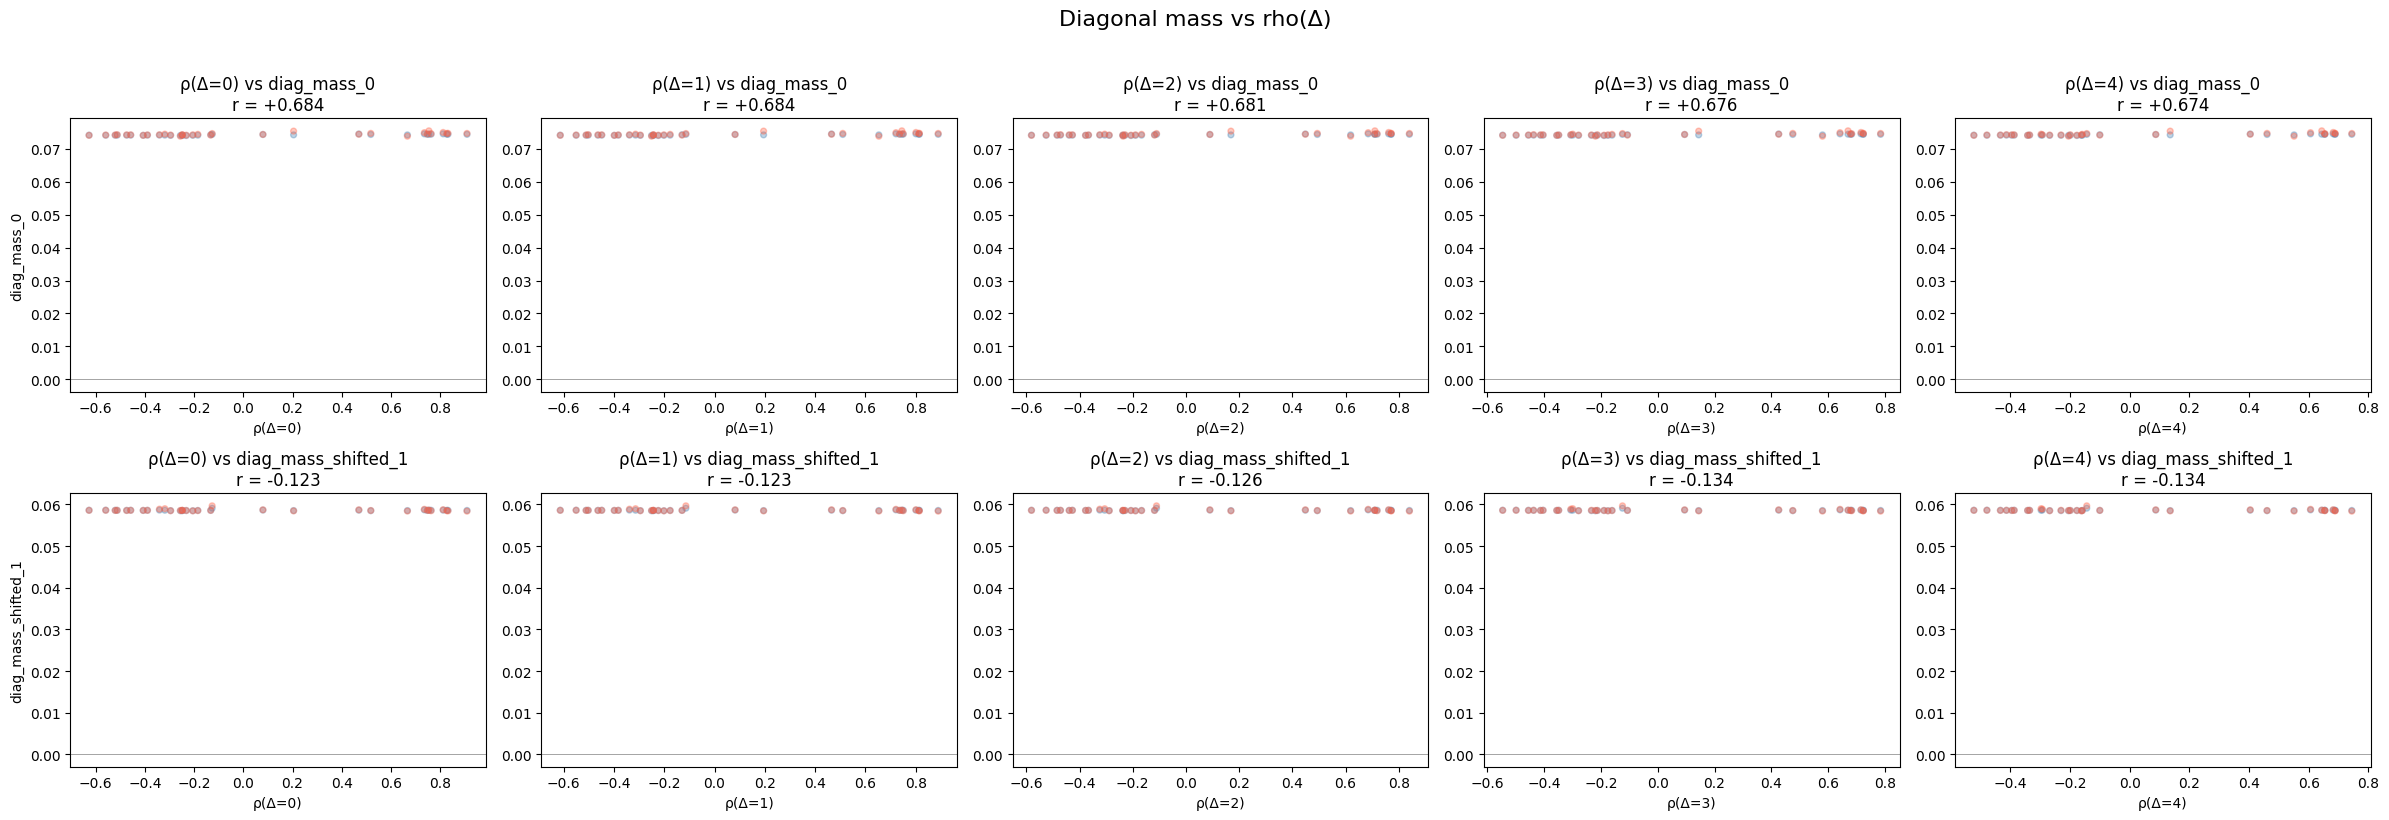

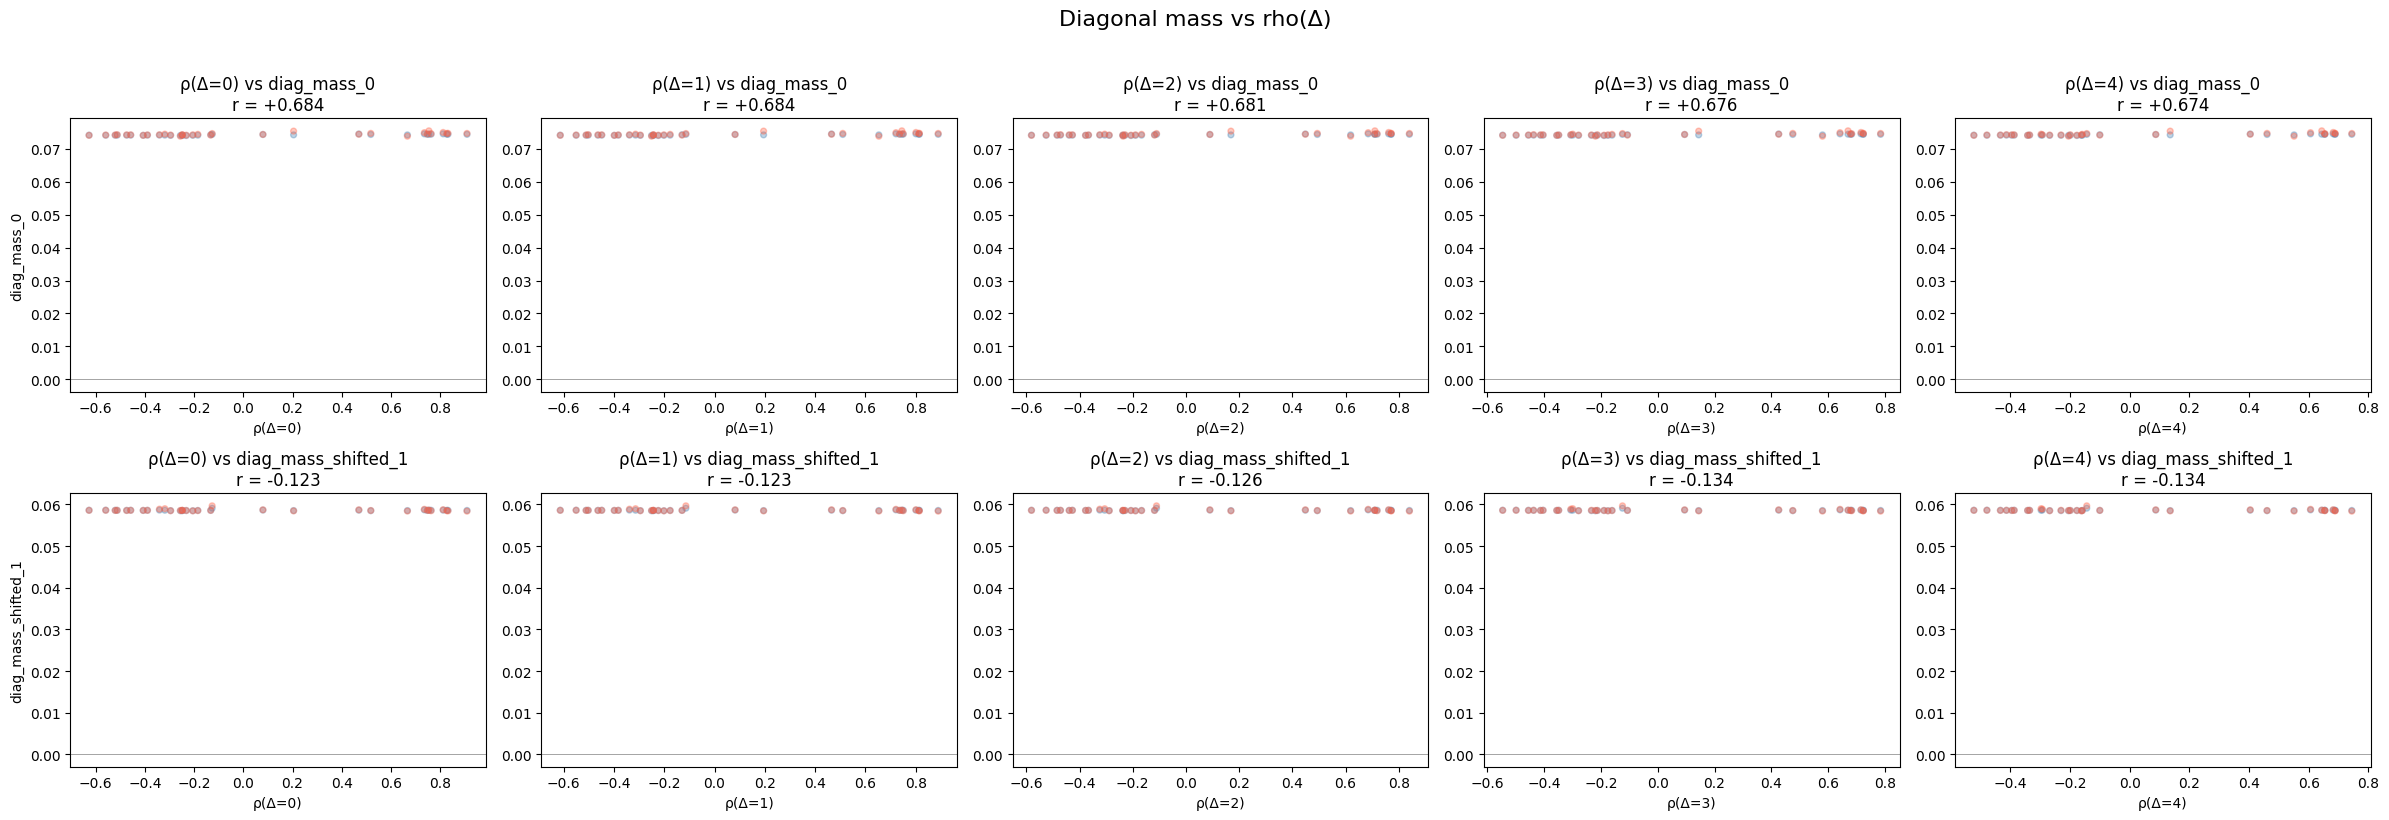

In [17]:
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

shift_q = 1
shift_col = f"diag_mass_shifted_{shift_q}" if f"diag_mass_shifted_{shift_q}" in df.columns else "diag_mass_shifted_1"

rho_cols = sorted(
    [col for col in df.columns if col.startswith("rho_")],
    key=lambda col: int(col.split("_")[1])
 )

fig, axes = plt.subplots(2, len(rho_cols), figsize=(4.8 * len(rho_cols), 8), sharex=False, sharey=False)
if len(rho_cols) == 1:
    axes = axes.reshape(2, 1)

clr_map = {"random": "steelblue", "wikitext": "tomato"}
c_pts = [clr_map[label] for label in df["label"]]

for j, rho_col in enumerate(rho_cols):
    delta = rho_col.split("_")[1]
    ax = axes[0, j]
    ax.scatter(df[rho_col], df["diag_mass_0"], c=c_pts, alpha=0.35, s=18, rasterized=True)
    r, _ = spearmanr(df[rho_col], df["diag_mass_0"])
    ax.set_title(f"ρ(Δ={delta}) vs diag_mass_0\nr = {r:+.3f}")
    ax.set_xlabel(f"ρ(Δ={delta})")
    if j == 0:
        ax.set_ylabel("diag_mass_0")
    ax.axhline(0, color="gray", lw=0.5)

    ax = axes[1, j]
    ax.scatter(df[rho_col], df[shift_col], c=c_pts, alpha=0.35, s=18, rasterized=True)
    r, _ = spearmanr(df[rho_col], df[shift_col])
    ax.set_title(f"ρ(Δ={delta}) vs {shift_col}\nr = {r:+.3f}")
    ax.set_xlabel(f"ρ(Δ={delta})")
    if j == 0:
        ax.set_ylabel(shift_col)
    ax.axhline(0, color="gray", lw=0.5)

fig.suptitle("Diagonal mass vs rho(Δ)", y=1.02, fontsize=16)
fig.tight_layout()
fig